In [103]:
import torch
# /home/work_nfs14/code/hkxie/ASR/understanding_LLM_task/code/test.ipynb
block_size=2;seq_len=7;t_p=1;t_f=1

# block_size=2;seq_len=7;t_p=1;t_f=1

indices = torch.arange(seq_len)
block_indices = indices // block_size  # 整除，得到每个 token 所属块的索引? 如果此时不是整数呢？


print(block_indices.unsqueeze(1))
print(block_indices.unsqueeze(0))
# 4.2 构造二维矩阵，计算任意两个位置所在块索引的差值
# diff[i, j] = block(i) - block(j)
diff = block_indices.unsqueeze(1) - block_indices.unsqueeze(0)  # shape: [seq_len, seq_len]
diff = block_indices.unsqueeze(0) - block_indices.unsqueeze(1)  # shape: [seq_len, seq_len]

print(f"diff=\n{diff}")

# 4.3 根据差值判断是否允许注意力：在 [-t_p, t_f] 范围内允许
computed_mask = (diff >= -t_p) & (diff <= t_f)  # bool tensor, shape: [seq_len, seq_len]
print(f"computed_mask=\n{computed_mask}")


tensor([[0],
        [0],
        [1],
        [1],
        [2],
        [2],
        [3]])
tensor([[0, 0, 1, 1, 2, 2, 3]])
diff=
tensor([[ 0,  0,  1,  1,  2,  2,  3],
        [ 0,  0,  1,  1,  2,  2,  3],
        [-1, -1,  0,  0,  1,  1,  2],
        [-1, -1,  0,  0,  1,  1,  2],
        [-2, -2, -1, -1,  0,  0,  1],
        [-2, -2, -1, -1,  0,  0,  1],
        [-3, -3, -2, -2, -1, -1,  0]])
computed_mask=
tensor([[ True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True, False],
        [False, False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True]])


In [13]:
target_sample_rate = 16000
n_mel_channels = 80
hop_length = 200
duration = 20
frame_length = int(duration * target_sample_rate / hop_length)
text_token_length = duration*25
inputs=(torch.randn(1, frame_length, n_mel_channels), torch.zeros(1, text_token_length, dtype=torch.long))
print(torch.zeros(1, text_token_length, dtype=torch.long).shape)
print(f"mel={torch.randn(1, frame_length, n_mel_channels)},\n{torch.randn(1, frame_length, n_mel_channels).shape}")

torch.Size([1, 500])
mel=tensor([[[-0.6744,  0.5373, -0.0553,  ..., -1.5460, -0.6755,  0.2240],
         [-0.2111, -0.9606, -1.3783,  ...,  0.1938,  0.5735,  0.2798],
         [-0.4704, -1.5045, -0.2212,  ...,  1.2334, -0.0062,  0.5317],
         ...,
         [ 0.8946,  0.8479,  0.5704,  ...,  0.7750,  1.7046, -0.3673],
         [-0.1489,  0.5776,  0.8341,  ...,  0.4312, -0.4948, -0.5402],
         [-0.4693,  0.5145, -0.3911,  ...,  0.6520,  1.2785, -1.4247]]]),
torch.Size([1, 1600, 80])


In [100]:
import numpy as np
# print(np.random.lognormal(0, 1, size=(1,)))
np.random.lognormal(0, 1, size=(1,))

time_np = np.random.lognormal(0, 1, size=(8,))
print(time_np)
time_np = (time_np - time_np.min()) / (time_np.max() - time_np.min() + 1e-8)
print(time_np)
time = torch.tensor(time_np)
print(time)

[1.38516458 0.57954587 0.69640832 1.59530568 2.36950458 0.49984907
 3.55799202 3.50719654]
[0.28949448 0.02606052 0.06427406 0.35820974 0.61136956 0.
 1.         0.98339009]
tensor([0.2895, 0.0261, 0.0643, 0.3582, 0.6114, 0.0000, 1.0000, 0.9834],
       dtype=torch.float64)


In [2]:
import torch
cond = torch.zeros(2,192)
print(cond.shape)
#[bs,192]
cond = cond.unsqueeze(1).repeat(1, 1200, 1)
print(cond.shape)
cond = torch.zeros(2,192)
cond = cond[:, None, :].expand(-1, 1200, -1)
print(cond.shape)

torch.Size([2, 192])
torch.Size([2, 1200, 192])
torch.Size([2, 1200, 192])


In [ ]:
txt = "/home/node57_data/hkxie/4O/streaming_fm/dataset/1whtraindataset.txt"
def filter_and_sum_duration(file_path, threshold=60.0, max_threshold=70.0):
    total_duration = 0.0
    count = 0
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 4:
                continue  # 跳过格式不匹配的行
            
            try:
                duration = float(parts[-1])  # 获取时长
                if threshold < duration :#< max_threshold
                    total_duration += duration
                    count += 1
            except ValueError:
                continue  # 跳过无法解析的行

    print(f"时长小于 {threshold}s 的数据行数: {count}")
    print(f"这些数据的总时长: {(total_duration/3600):.2f}小时")

# 使用方法：
file_path = "/home/node57_data/hkxie/4O/streaming_fm/dataset/1whtraindataset.txt"
file_path = "/home/work_nfs14/code/hkxie/ASR/understanding_LLM_task/10wh_list/combined.txt"
filter_and_sum_duration(file_path)


时长小于 1.0s 的数据行数: 5766061
这些数据的总时长: 10833.65小时


In [ ]:
import numpy as np
file_path = "/home/node57_data/hkxie/4O/streaming_fm/dataset/1whtraindataset.txt"    
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 4:
            continue  # 跳过格式不匹配的行
        mel_path = parts[1]
        token_path = parts[2]
        duration = parts[3]
        mel = np.load(mel_path)
        token = np.load(token_path)
        print(f"mel.shape={mel.shape},\ntoken.shape={token.shape},\nduration={duration}")

In [2]:
import numpy as np

# 定义文件路径
output_path_gen = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/test/gen_mel_spec.npy"
output_path_gen2 = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/test/gen_mel_spec2_streaming.npy"

# 加载 .npy 文件
gen_mel_spec = np.load(output_path_gen)
gen_mel_spec2 = np.load(output_path_gen2)

# 确认形状
print(f"gen_mel_spec shape: {gen_mel_spec.shape}")
print(f"gen_mel_spec2 shape: {gen_mel_spec2.shape}")

# 找到最小的时间维度长度
min_time_dim = min(gen_mel_spec.shape[2], gen_mel_spec2.shape[2])

# 裁剪到最小时间维度长度
gen_mel_spec_cropped = gen_mel_spec[:, :, :min_time_dim]
gen_mel_spec2_cropped = gen_mel_spec2[:, :, :min_time_dim]

# 计算差值
diff = np.abs(gen_mel_spec_cropped - gen_mel_spec2_cropped)

# 输出差值信息
mean_diff = np.mean(diff)
max_diff = np.max(diff)
min_diff = np.min(diff)
print(diff)
print(f"Mean difference: {mean_diff}")
print(f"Max difference: {max_diff}")
print(f"Min difference: {min_diff}")

# 如果需要进一步分析，可以保存差值结果
np.save("/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/test/diff_mel_spec.npy", diff)

print("Difference calculation complete.")

gen_mel_spec shape: (1, 80, 867)
gen_mel_spec2 shape: (1, 80, 900)
[[[2.44140625e-03 9.76562500e-03 1.41601562e-02 ... 4.66796875e-01
   4.65454102e-01 4.51965332e-01]
  [3.90625000e-03 1.75781250e-02 1.41601562e-02 ... 3.57574463e-01
   3.62136841e-01 3.52710724e-01]
  [2.44140625e-03 2.29492188e-02 1.46484375e-02 ... 2.72460938e-01
   2.82257080e-01 2.85400391e-01]
  ...
  [3.90625000e-03 4.88281250e-03 0.00000000e+00 ... 5.10620117e-01
   5.63964844e-01 5.80963135e-01]
  [1.95312500e-03 2.92968750e-03 4.88281250e-04 ... 5.62805176e-01
   6.12243652e-01 6.28784180e-01]
  [0.00000000e+00 9.76562500e-04 1.46484375e-03 ... 6.17675781e-01
   6.64306641e-01 6.81152344e-01]]]
Mean difference: 0.1912415772676468
Max difference: 1.09521484375
Min difference: 0.0
Difference calculation complete.


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

原始形状: (1, 80, 867) vs (1, 80, 900)


/tmp/ipykernel_613543/1256181135.py:74: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.savefig(f"{save_path}/spectrum_comparison.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_613543/1256181135.py:74: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.savefig(f"{save_path}/spectrum_comparison.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_613543/1256181135.py:74: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from current font.
  plt.savefig(f"{save_path}/spectrum_comparison.png", dpi=300, bbox_inches='tight')
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/output/directory//spectrum_comparison.png'

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

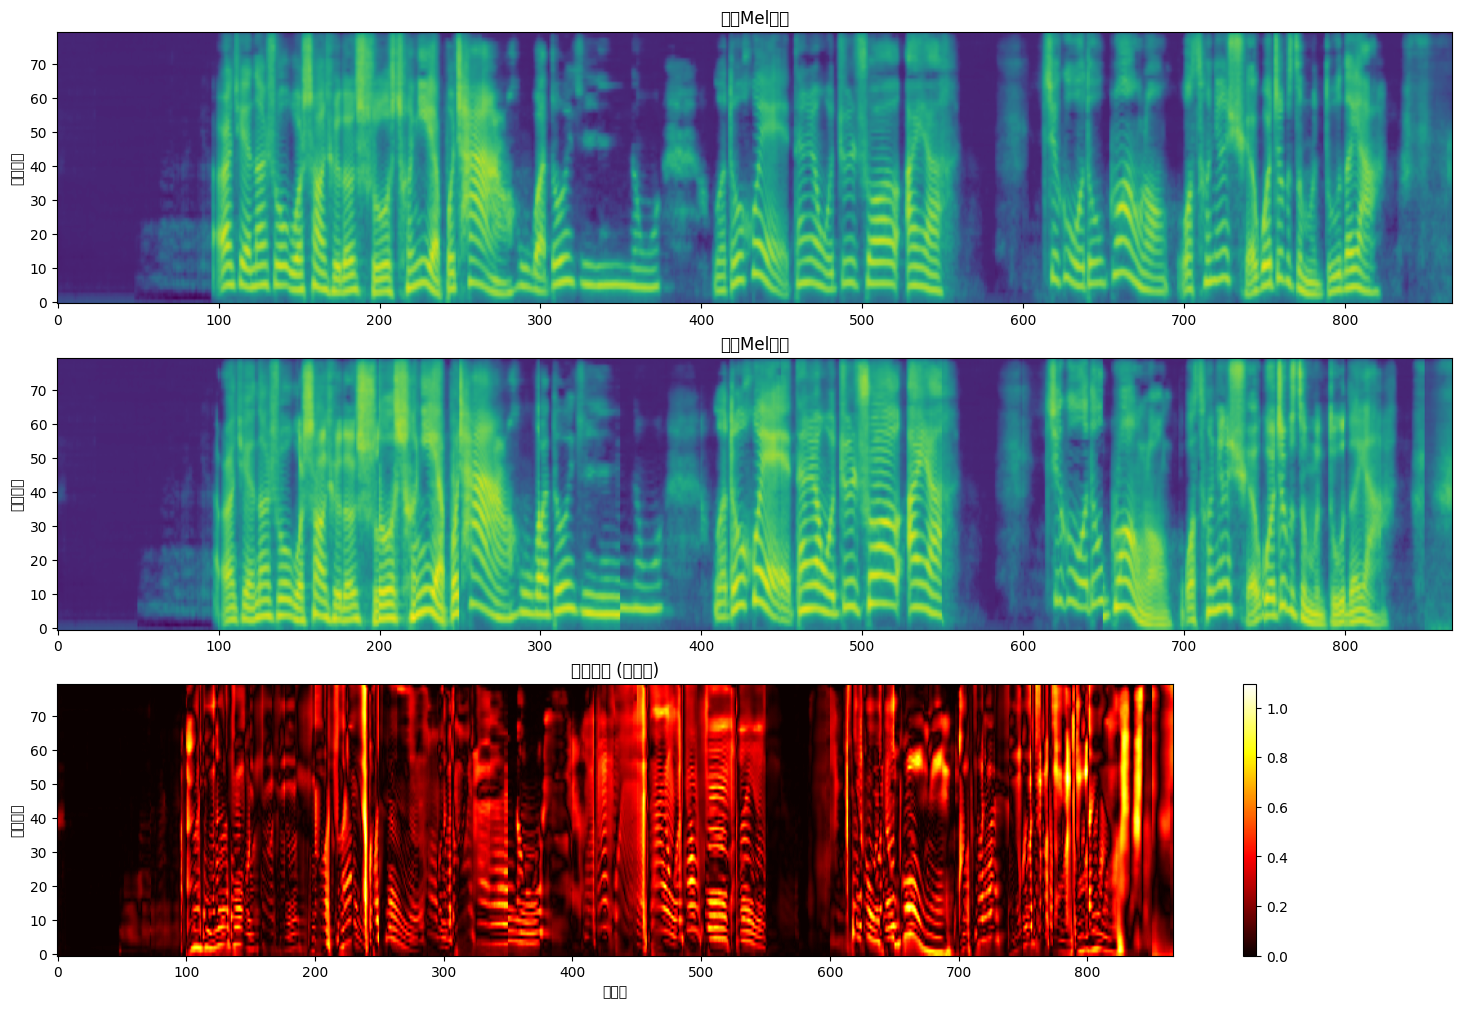

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ================== 配置参数 ==================
output_path_gen = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/test/gen_mel_spec.npy"
output_path_gen2 = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/test/gen_mel_spec2_streaming.npy"
output_dir = "/path/to/output/directory/"
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False    # 负号显示

# ================== 数据加载与预处理 ==================
def load_and_align_mels(path1, path2):
    """加载并对齐两个mel频谱"""
    mel1 = np.load(path1)
    mel2 = np.load(path2)
    
    print(f"原始形状: {mel1.shape} vs {mel2.shape}")
    
    # 对齐时间维度
    min_time = min(mel1.shape[2], mel2.shape[2])
    return mel1[..., :min_time], mel2[..., :min_time]

mel_ref, mel_stream = load_and_align_mels(output_path_gen, output_path_gen2)

# ================== 差异分析 ==================
def compute_differences(ref, test):
    """计算多种差异指标"""
    metrics = {
        'MSE': np.mean((ref - test)**2),
        'MAE': np.mean(np.abs(ref - test)),
        'MaxAE': np.max(np.abs(ref - test)),
        'PSNR': 10 * np.log10(1 / (np.mean((ref - test)**2) + 1e-10))
    }
    
    # 分帧差异计算
    frame_mse = np.mean((ref - test)**2, axis=(0,1))
    return metrics, frame_mse

metrics, frame_mse = compute_differences(mel_ref, mel_stream)

# ================== 可视化 ==================
def plot_comparison(ref, test, diff, frame_mse, save_path):
    """绘制对比可视化图表"""
    plt.figure(figsize=(18, 12))
    
    # 通用归一化
    vmin = min(ref.min(), test.min())
    vmax = max(ref.max(), test.max())
    norm = Normalize(vmin, vmax)
    
    # 原始mel频谱
    plt.subplot(3, 1, 1)
    plt.imshow(ref[0], aspect='auto', origin='lower', norm=norm)
    plt.title("原始Mel频谱")
    plt.ylabel("频率通道")
    
    # 流式mel频谱
    plt.subplot(3, 1, 2)
    plt.imshow(test[0], aspect='auto', origin='lower', norm=norm)
    plt.title("流式Mel频谱")
    plt.ylabel("频率通道")
    
    # 差异频谱
    plt.subplot(3, 1, 3)
    plt.imshow(diff[0], aspect='auto', origin='lower', 
              cmap='hot', norm=Normalize(0, diff.max()))
    plt.title("差异频谱 (绝对值)")
    plt.xlabel("时间帧")
    plt.ylabel("频率通道")
    plt.colorbar()
    
    # 保存图像
    plt.savefig(f"{save_path}/spectrum_comparison.png", dpi=300, bbox_inches='tight')
    
    # 分帧MSE曲线
    plt.figure(figsize=(12, 6))
    plt.plot(frame_mse, linewidth=1)
    plt.title("分帧MSE变化曲线")
    plt.xlabel("时间帧")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.savefig(f"{save_path}/frame_mse.png", dpi=200, bbox_inches='tight')

# ================== 结果输出 ==================
def save_report(metrics, save_path):
    """保存文本报告"""
    with open(f"{save_path}/report.txt", 'w') as f:
        f.write("===== 频谱差异分析报告 =====\n")
        f.write(f"平均MSE: {metrics['MSE']:.4e}\n")
        f.write(f"平均MAE: {metrics['MAE']:.4f}\n") 
        f.write(f"最大绝对误差: {metrics['MaxAE']:.4f}\n")
        f.write(f"PSNR: {metrics['PSNR']:.2f} dB\n")

# 执行分析
diff = np.abs(mel_ref - mel_stream)
plot_comparison(mel_ref, mel_stream, diff, frame_mse, output_dir)
save_report(metrics, output_dir)

# ================== 附加分析 ==================
# 统计高频区域差异（假设高频在通道30-80）
high_freq_diff = np.mean(diff[:, 30:80, :])
print(f"高频区域平均差异: {high_freq_diff:.4f}")

print("分析完成，结果已保存至:", output_dir)

In [10]:
import sys
sys.path.append("/home/node57_data/hkxie/4O/F5-TTS/src/")
# from f5_tts.model.mel_processing import mel_spectrogram_torch_aslp
wav_path = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/cosyvoice2_token_test/ICAGC_8-3-12.wav"
# ref_path = "/home/work_nfs14/dkguo/TTS_Testset/lm/promptset/hq_set/mels/DB_TTS_0412_000185.npy" #(80, 726)
import numpy as np
# token = np.load(token_path)
# audio , sample_rate = torchaudio.load(wav_path)
# mel_spec = mel_spectrogram_torch_aslp(y=audio, n_fft=1024, num_mels=80, sampling_rate=16000, hop_size=160, win_size=640, fmin=0, fmax=8000, center=False)
# print(mel_spec.shape)
# import pdb;pdb.set_trace()

import yaml
# from importlib.resources import files
config_path = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/configs/fm_10ms_cosyvoice1.yaml"

with open(config_path, 'r') as file:  
    config = yaml.safe_load(file) 
print(config)
# model_cfg = config.get("model_cfg", str(files("f5_tts").joinpath("configs/fm_10ms_cosyvoice1.yaml")))
model_cfg = config.get("model_cfg", "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/configs/fm_10ms_cosyvoice1.yaml")
print(model_cfg)

{'hydra': {'run': {'dir': 'ckpts/${model.name}_${model.mel_spec.mel_spec_type}${model.tokenizer}/${now:%Y-%m-%d}/${now:%H-%M-%S}'}}, 'datasets': {'name': '1whtrain_online_dataset_cosyvoice1.txt', 'dataset_type': 'OnlineDataset', 'batch_size_per_gpu': 1200, 'batch_size_type': 'frame', 'max_samples': 16, 'num_workers': 16}, 'optim': {'epochs': 50, 'learning_rate': 7.5e-05, 'num_warmup_updates': 20000, 'grad_accumulation_steps': 1, 'max_grad_norm': 1.0, 'bnb_optimizer': False}, 'model': {'name': 'F5TTS_fm_10ms', 'tokenizer': 'cosyvoice1', 'tokenizer_path': 'None', 'text_num_embeds': 4096, 'arch': {'dim': 768, 'depth': 22, 'heads': 16, 'ff_mult': 2, 'text_dim': 512, 'conv_layers': 4, 'checkpoint_activations': False}, 'mel_spec': {'target_sample_rate': 16000, 'n_mel_channels': 80, 'hop_length': 160, 'win_length': 640, 'n_fft': 1024, 'mel_spec_type': 'dspgan'}, 'vocoder': {'is_local': False, 'local_path': 'None'}}, 'ckpts': {'logger': 'wandb', 'save_per_updates': 50000, 'keep_last_n_checkpoi

In [6]:
import onnxruntime
import json
# from importlib.resources import files
import os
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.compliance.kaldi as kaldi

def _extract_spk_embedding(speech): #campplus_model str查看一下
    option = onnxruntime.SessionOptions()
    option.graph_optimization_level = onnxruntime.GraphOptimizationLevel.ORT_ENABLE_ALL
    option.intra_op_num_threads = 1
    campplus_session = onnxruntime.InferenceSession("/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/model/campplus.onnx", sess_options=option, providers=["CPUExecutionProvider"])
    feat = kaldi.fbank(speech,
                        num_mel_bins=80,
                        dither=0,
                        sample_frequency=16000)
    feat = feat - feat.mean(dim=0, keepdim=True)
    embedding = campplus_session.run(None,{campplus_session.get_inputs()[0].name: feat.unsqueeze(dim=0).cpu().numpy()})[0].flatten().tolist()
    embedding = torch.tensor([embedding])#.to(self.device)
    return embedding

wav_path = "/home/node57_data/hkxie/4O/F5-TTS/src/f5_tts/infer/cosyvoice2_token_test/ICAGC_8-3-12.wav"
# 加载音频并生成 mel 频谱
audio, sample_rate = torchaudio.load(wav_path)
# make sure mono input
if audio.shape[0] > 1:
    audio = torch.mean(audio, dim=0, keepdim=True)

# resample if necessary
if sample_rate != 16000:
    resampler = torchaudio.transforms.Resample(sample_rate, 16000)
    audio = resampler(audio)

spk_embed = _extract_spk_embedding(audio)
print(spk_embed.shape)


torch.Size([1, 192])


In [5]:
target_len = 1200
src_len = 299
print((target_len + src_len - 1) // src_len)

5
